In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Activation, Add, Multiply, Reshape, Lambda, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

Training images shape: (392, 128, 128, 1)
Training masks shape: (392, 128, 128, 1)
Validation images shape: (196, 128, 128, 1)
Validation masks shape: (196, 128, 128, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 128, 128,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_38[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 128, 128,  │        128 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 128, 128,  │          0 │ add_22[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_39[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_66[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_40       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 128, 128,  │     36,928 │ activation_40[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_67[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_39[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 128, 128,  │          0 │ add_23[0][0]    

 Total params: 33,740,101 (128.71 MB)

 Trainable params: 33,717,061 (128.62 MB)

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.9526 - accuracy_metric: 0.9526 - dice_coef: 0.6854 - iou_metric: 0.6763 - loss: 0.1248 - precision_metric: 0.8261 - recall_metric: 0.7937 - val_accuracy: 0.9450 - val_accuracy_metric: 0.9450 - val_dice_coef: 0.6607 - val_iou_metric: 0.6253 - val_loss: 0.1429 - val_precision_metric: 0.8930 - val_recall_metric: 0.6812
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9544 - accuracy_metric: 0.9544 - dice_coef: 0.6972 - iou_metric: 0.6781 - loss: 0.1185 - precision_metric: 0.8305 - recall_metric: 0.7917
Epoch 8: val_loss improved from 0.14290 to 0.12344, saving model to hmsam_resunet_attention_nuclei_tuned.h5


98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.9544 - accuracy_metric: 0.9544 - dice_coef: 0.6972 - iou_metric: 0.6780 - loss: 0.1186 - precision_metric: 0.8304 - recall_metric: 0.7916 - val_accuracy: 0.9522 - val_accuracy_metric: 0.9522 - val_dice_coef: 0.7192 - val_iou_metric: 0.6694 - val_loss: 0.1234 - val_precision_metric: 0.9171 - val_recall_metric: 0.7157
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9553 - accuracy_metric: 0.9553 - dice_coef: 0.7378 - iou_metric: 0.7150 - loss: 0.1154 - precision_metric: 0.8550 - recall_metric: 0.8166
Epoch 9: val_loss did not improve from 0.12344
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.9552 - accuracy_metric: 0.9552 - dice_coef: 0.7376 - iou_metric: 0.7147 - loss: 0.1155 - precision_metric: 0.8548 - recall_metric: 0.8164 - val_accuracy: 0.9485 - val_accuracy_metric: 0.9485 - val_dice_coef: 0.7063 - val_iou_metric: 0.6436 - val_loss: 0.1244 - val_precision_metric: 0.9357 - val_recall_metric: 0.6774
E

98/98 ━━━━━━━━━━━━━━━━━━━━ 46s 274ms/step - accuracy: 0.9616 - accuracy_metric: 0.9616 - dice_coef: 0.7497 - iou_metric: 0.7268 - loss: 0.0988 - precision_metric: 0.8559 - recall_metric: 0.8243 - val_accuracy: 0.9548 - val_accuracy_metric: 0.9548 - val_dice_coef: 0.7512 - val_iou_metric: 0.6855 - val_loss: 0.1162 - val_precision_metric: 0.9325 - val_recall_metric: 0.7255
Epoch 16/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9572 - accuracy_metric: 0.9572 - dice_coef: 0.7515 - iou_metric: 0.7235 - loss: 0.1089 - precision_metric: 0.8509 - recall_metric: 0.8327
Epoch 16: val_loss improved from 0.11622 to 0.10575, saving model to hmsam_resunet_attention_nuclei_tuned.h5


98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.9572 - accuracy_metric: 0.9572 - dice_coef: 0.7516 - iou_metric: 0.7236 - loss: 0.1088 - precision_metric: 0.8510 - recall_metric: 0.8327 - val_accuracy: 0.9609 - val_accuracy_metric: 0.9609 - val_dice_coef: 0.7722 - val_iou_metric: 0.7286 - val_loss: 0.1057 - val_precision_metric: 0.9238 - val_recall_metric: 0.7780
Epoch 17/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9622 - accuracy_metric: 0.9622 - dice_coef: 0.7710 - iou_metric: 0.7424 - loss: 0.0965 - precision_metric: 0.8679 - recall_metric: 0.8400
Epoch 17: val_loss did not improve from 0.10575
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 216ms/step - accuracy: 0.9622 - accuracy_metric: 0.9622 - dice_coef: 0.7709 - iou_metric: 0.7424 - loss: 0.0965 - precision_metric: 0.8679 - recall_metric: 0.8400 - val_accuracy: 0.9601 - val_accuracy_metric: 0.9601 - val_dice_coef: 0.7359 - val_iou_metric: 0.7360 - val_loss: 0.1144 - val_precision_metric: 0.8731 - val_recall_metric: 0.8289

98/98 ━━━━━━━━━━━━━━━━━━━━ 47s 283ms/step - accuracy: 0.9609 - accuracy_metric: 0.9609 - dice_coef: 0.7590 - iou_metric: 0.7343 - loss: 0.1003 - precision_metric: 0.8565 - recall_metric: 0.8415 - val_accuracy: 0.9599 - val_accuracy_metric: 0.9599 - val_dice_coef: 0.7647 - val_iou_metric: 0.7233 - val_loss: 0.1017 - val_precision_metric: 0.9232 - val_recall_metric: 0.7710
Epoch 19/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9601 - accuracy_metric: 0.9601 - dice_coef: 0.7509 - iou_metric: 0.7215 - loss: 0.1030 - precision_metric: 0.8492 - recall_metric: 0.8253
Epoch 19: val_loss did not improve from 0.10168
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 220ms/step - accuracy: 0.9601 - accuracy_metric: 0.9601 - dice_coef: 0.7510 - iou_metric: 0.7217 - loss: 0.1029 - precision_metric: 0.8493 - recall_metric: 0.8255 - val_accuracy: 0.9590 - val_accuracy_metric: 0.9590 - val_dice_coef: 0.7737 - val_iou_metric: 0.7135 - val_loss: 0.1115 - val_precision_metric: 0.9346 - val_recall_metric: 0.7543

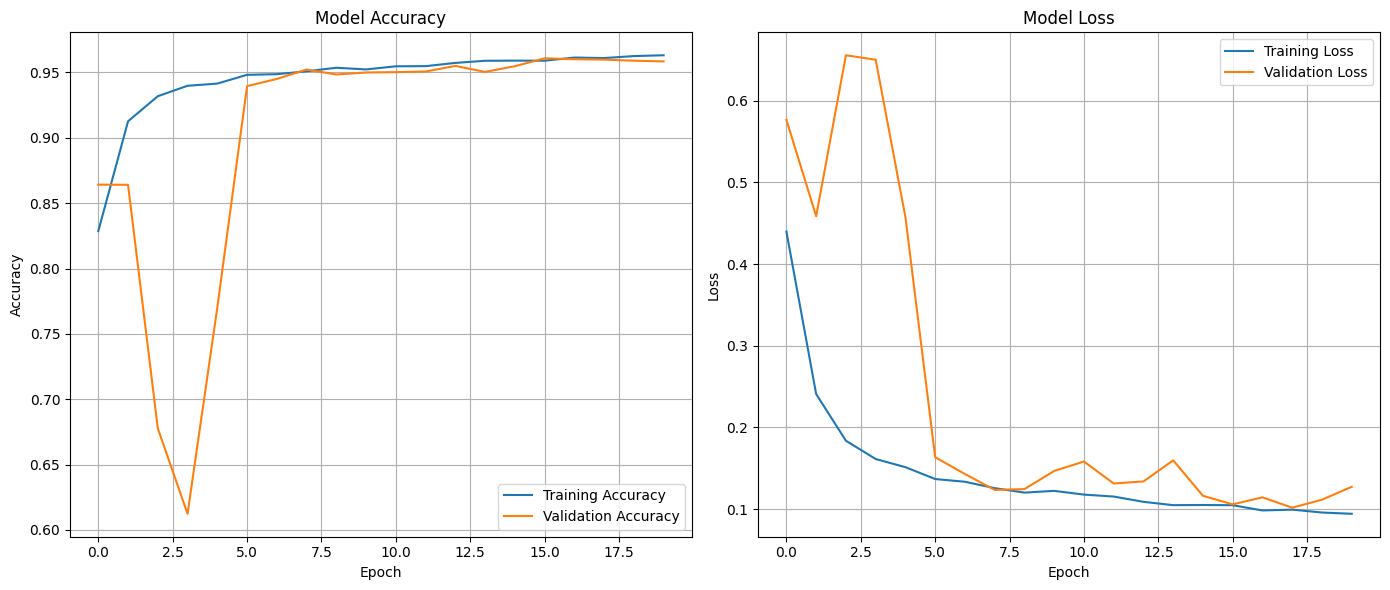


--- Visualizing Predictions on Validation Set (Modified Model with Attention Gates - Tuned) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


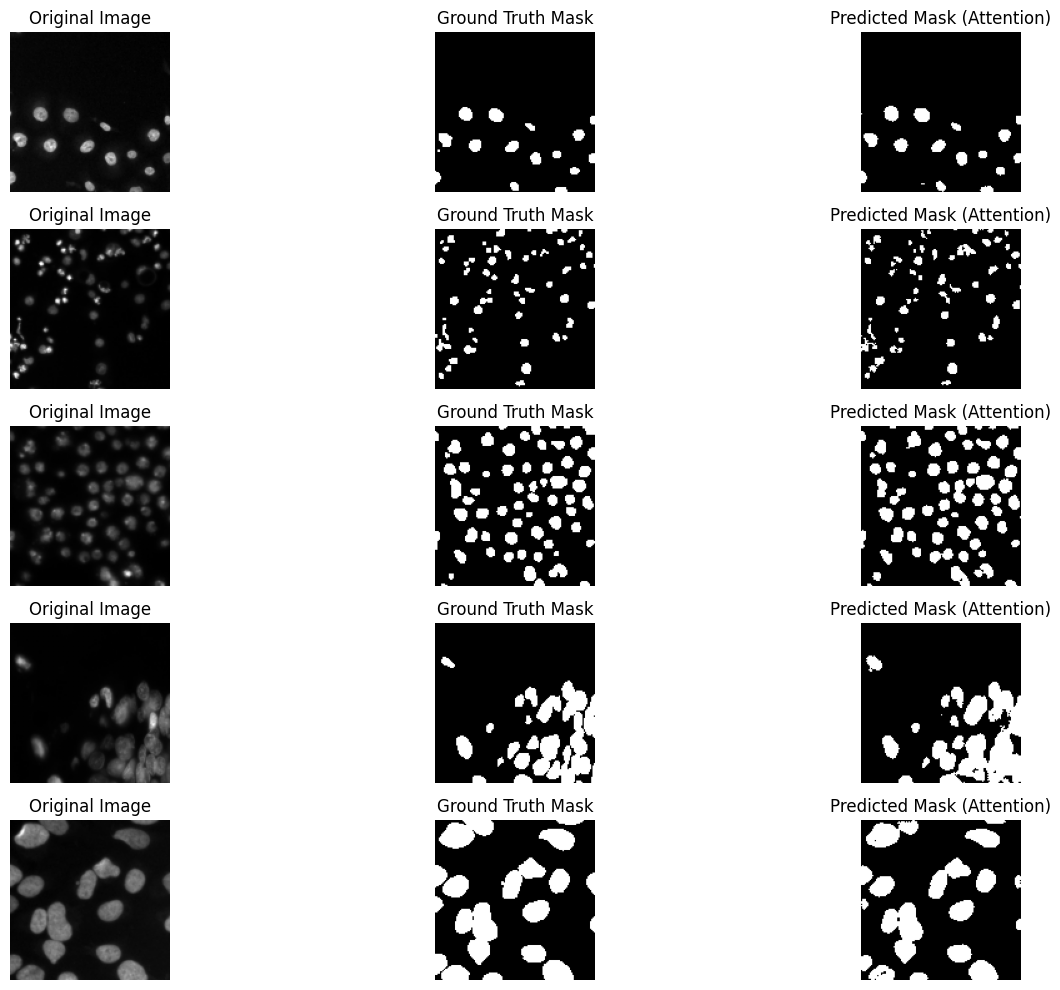

Trained tuned modified model with Attention Gates saved as hmsam_resunet_attention_nuclei_tuned_trained.h5


In [ ]:
# --- Data Paths ---
DATA_DIR = '/content/drive/MyDrive/NucleiSegmentation' # Adjust this to your main dataset directory
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'testi/images')
TRAIN_MASK_DIR = os.path.join(DATA_DIR, 'testi/masks')

TEST_IMG_DIR = os.path.join(DATA_DIR, 'NucleiSegmentationDataset/all_images')
TEST_MASKS_DIR = os.path.join(DATA_DIR, 'NucleiSegmentationDataset/merged_masks')

# --- Parameters ---
IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 1
NUM_CLASSES = 1
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 2e-5
VALIDATION_SPLIT = 0.5
EVAL_BATCH_SIZE = 1

def load_data(img_dir, mask_dir, img_height, img_width, channels):
    images = []
    masks = []
    img_filenames = sorted(os.listdir(img_dir))
    mask_filenames = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(img_filenames, mask_filenames):
        if not img_file.startswith('.') and not mask_file.startswith('.'):
            img_path = os.path.join(img_dir, img_file)
            mask_path = os.path.join(mask_dir, mask_file)

            img = io.imread(img_path)
            mask = io.imread(mask_path)

            if img.ndim == 3 and img.shape[2] == 4:
                img = img[:, :, :3]
            if img.ndim == 3:
                img = color.rgb2gray(img)

            if mask.ndim == 3 and mask.shape[2] == 4:
                mask = mask[:, :, :3]
            if mask.ndim == 3:
                mask = color.rgb2gray(mask)

            img_resized = resize(img, (img_width, img_height), anti_aliasing=True)
            mask_resized = resize(mask, (img_width, img_height), anti_aliasing=True)
            mask_binary = (mask_resized > 0.5).astype(np.float32)
            img_resized = np.expand_dims(img_resized, axis=-1).astype(np.float32)
            mask_binary = np.expand_dims(mask_binary, axis=-1)

            images.append(img_resized)
            masks.append(mask_binary)

    return np.array(images), np.array(masks)

# Load all training data
X, Y = load_data(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Split the data into training and validation sets
X_tame, X_val, Y_tame, Y_val = train_test_split(X, Y, test_size=VALIDATION_SPLIT, random_state=42)

X_train = X
Y_train = Y

print(f"Training images shape: {X_train.shape}")
print(f"Training masks shape: {Y_train.shape}")
print(f"Validation images shape: {X_val.shape}")
print(f"Validation masks shape: {Y_val.shape}")

# --- Squeeze-and-Excitation Block ---
def se_block(input_feature, ratio=4):
    channel = input_feature.shape[-1]
    squeeze = GlobalAveragePooling2D()(input_feature)
    excitation = Dense(units=channel // ratio, activation='relu')(squeeze)
    excitation = Dense(units=channel, activation='sigmoid')(excitation)
    excitation = Reshape((1, 1, channel))(excitation)
    scaled_feature = Multiply()([input_feature, excitation])
    return scaled_feature

def non_local_block(input_tensor, compression=2, mode='embedded_gaussian'):
    channel = input_tensor.shape[-1]
    compressed_channels = channel // compression

    # Theta path
    theta = Conv2D(compressed_channels, (1, 1), padding='same')(input_tensor)
    theta_reshaped = Reshape((-1, compressed_channels))(theta)

    # Phi path
    phi = Conv2D(compressed_channels, (1, 1), padding='same')(input_tensor)
    phi_reshaped = Reshape((-1, compressed_channels))(phi)
    phi_transposed = Lambda(lambda x: tf.transpose(x, [0, 2, 1]))(phi_reshaped)

    attention = Lambda(lambda x: tf.matmul(x[0], x[1]))([theta_reshaped, phi_transposed])
    if mode == 'embedded_gaussian':
        attention = Activation('softmax')(attention)


    g = Conv2D(channel // 2, (1, 1), padding='same')(input_tensor)
    g_reshaped = Reshape((-1, channel // 2))(g)
    weighted_sum = Lambda(lambda x: tf.matmul(x[0], x[1]))([attention, g_reshaped])

    height = input_tensor.shape[1]
    width = input_tensor.shape[2]
    if height is None or width is None:
        raise ValueError("Input tensor must have static height and width dimensions")

    weighted_sum_reshaped = Reshape((height, width, channel // 2))(weighted_sum)

    w = Conv2D(channel, (1, 1), padding='same')(weighted_sum_reshaped)
    output = Add()([input_tensor, w])
    return output

# --- Inception Module with SE ---
def inception_module_se(input_tensor, out_channels_1x1, red_channels_3x3, out_channels_3x3, red_channels_5x5, out_channels_5x5, pool_proj):
    branch1 = Conv2D(out_channels_1x1, (1, 1), padding='same', activation='relu')(input_tensor)
    branch1_se = se_block(branch1)

    branch2 = Conv2D(red_channels_3x3, (1, 1), padding='same', activation='relu')(input_tensor)
    branch2 = Conv2D(out_channels_3x3, (3, 3), padding='same', activation='relu')(branch2)
    branch2_se = se_block(branch2)

    branch3 = Conv2D(red_channels_5x5, (1, 1), padding='same', activation='relu')(input_tensor)
    branch3 = Conv2D(out_channels_5x5, (5, 5), padding='same', activation='relu')(branch3)
    branch3_se = se_block(branch3)

    branch4 = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(input_tensor)
    branch4 = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(branch4)
    branch4_se = se_block(branch4)

    output = concatenate([branch1_se, branch2_se, branch3_se, branch4_se], axis=-1)
    return output

# --- HMSA Module with SE Inception and Non-Local Attention ---
def hmsa_module(input_tensor, in_channels, out_channels_1x1, red_channels_3x3, out_channels_3x3, red_channels_5x5, out_channels_5x5, pool_proj):
    inception_out = inception_module_se(input_tensor, out_channels_1x1, red_channels_3x3, out_channels_3x3, red_channels_5x5, out_channels_5x5, pool_proj)
    non_local_out = non_local_block(inception_out)
    inception_output_channels = out_channels_1x1 + out_channels_3x3 + out_channels_5x5 + pool_proj
    if inception_output_channels != in_channels:
        projection = Conv2D(in_channels, (1, 1), padding='same')(non_local_out)
        hmsam_output = Add()([input_tensor, projection])
    else:
        hmsam_output = Add()([input_tensor, non_local_out])
    return Activation('relu')(hmsam_output)

# --- Residual Block in Keras ---
def residual_block(input_tensor, filters, stride=1):
    conv1 = Conv2D(filters, (3, 3), padding='same', strides=stride)(input_tensor)
    bn1 = BatchNormalization()(conv1)
    relu1 = Activation('relu')(bn1)
    conv2 = Conv2D(filters, (3, 3), padding='same')(relu1)
    bn2 = BatchNormalization()(conv2)

    if stride != 1 or input_tensor.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), padding='same', strides=stride)(input_tensor)
        shortcut = BatchNormalization()(shortcut)
        merged = Add()([bn2, shortcut])
    else:
        merged = Add()([bn2, input_tensor])
    return Activation('relu')(merged)

# --- UpSample Layer in Keras ---
def upsample_block(input_tensor, filters):
    up = Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same')(input_tensor)
    return up

# --- Attention Gate Module ---
def attention_block(x, skip_connection):
    filters = skip_connection.shape[-1]

    g = Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    g = BatchNormalization()(g)

    # Input from the encoder (skip connection)
    s = Conv2D(filters, (1, 1), padding='same', activation='relu')(skip_connection)
    s = BatchNormalization()(s)

    psi = Add()([g, s])
    psi = Activation('relu')(psi)

    psi = Conv2D(1, (1, 1), padding='same', activation='sigmoid')(psi)
    attention_output = Multiply()([skip_connection, psi])
    return attention_output

# --- HMSAM-ResUNet Model in Keras with HMSA and Attention Gates ---
def senla_resunet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape)

    # Encoder
    enc1_res1 = residual_block(inputs, 64)
    enc1_res2 = residual_block(enc1_res1, 64)
    pool1 = MaxPooling2D((2, 2))(enc1_res2)

    enc2_res1 = residual_block(pool1, 128)
    enc2_res2 = residual_block(enc2_res1, 128)
    pool2 = MaxPooling2D((2, 2))(enc2_res2)

    enc3_res1 = residual_block(pool2, 256)
    enc3_res2 = residual_block(enc3_res1, 256)
    pool3 = MaxPooling2D((2, 2))(enc3_res2)

    enc4_res1 = residual_block(pool3, 512)
    enc4_res2 = residual_block(enc4_res1, 512)
    pool4 = MaxPooling2D((2, 2))(enc4_res2)

    # Bridge
    hmsa_out = hmsa_module(pool4, in_channels=512,
                                        out_channels_1x1=128,
                                        red_channels_3x3=96, out_channels_3x3=192,
                                        red_channels_5x5=32, out_channels_5x5=64,
                                        pool_proj=128)

    # Decoder with Attention Gates
    up4 = upsample_block(hmsa_out, 512)
    attention4 = attention_block(up4, enc4_res2)
    concat4 = concatenate([up4, attention4], axis=-1)
    dec4_res1 = residual_block(concat4, 512)
    dec4_res2 = residual_block(dec4_res1, 512)

    up3 = upsample_block(dec4_res2, 256)
    attention3 = attention_block(up3, enc3_res2)
    concat3 = concatenate([up3, attention3], axis=-1)
    dec3_res1 = residual_block(concat3, 256)
    dec3_res2 = residual_block(dec3_res1, 256)

    up2 = upsample_block(dec3_res2, 128)
    attention2 = attention_block(up2, enc2_res2)
    concat2 = concatenate([up2, attention2], axis=-1)
    dec2_res1 = residual_block(concat2, 128)
    dec2_res2 = residual_block(dec2_res1, 128)

    up1 = upsample_block(dec2_res2, 64)
    attention1 = attention_block(up1, enc1_res2)
    concat1 = concatenate([up1, attention1], axis=-1)
    dec1_res1 = residual_block(concat1, 64)
    dec1_res2 = residual_block(dec1_res1, 64)

    outputs = Conv2D(num_classes, (1, 1), activation='sigmoid')(dec1_res2)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Instantiate the SENLA-ResUNet model with Attention Gates
model_attention = senla_resunet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES)

# --- Metrics ---
def iou_metric(y_true, y_pred):
    intersection = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    union = K.sum(K.round(K.clip(y_true, 0, 1))) + K.sum(K.round(K.clip(y_pred, 0, 1))) - intersection
    iou = K.mean((intersection + K.epsilon()) / (union + K.epsilon()))
    return iou

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

def precision_metric(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = (true_positives + K.epsilon()) / (predicted_positives + K.epsilon())
    return precision

def recall_metric(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    actual_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = (true_positives + K.epsilon()) / (actual_positives + K.epsilon())
    return recall

def accuracy_metric(y_true, y_pred):
    return K.mean(K.equal(K.round(y_true), K.round(y_pred)))

# Compile the model with Attention Gates
model_attention.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                        loss='binary_crossentropy',
                        metrics=['accuracy', iou_metric, dice_coef, precision_metric, recall_metric, accuracy_metric])

model_attention.summary()

# --- Callbacks ---
early_stopping_attention = EarlyStopping(monitor='val_loss', patience=30, verbose=1) # Adjusted patience
model_checkpoint_attention = ModelCheckpoint('senla_resunet_nuclei_tuned.h5', monitor='val_loss', save_best_only=True, verbose=1)

# --- Train the Model with Attention Gates ---
history_attention = model_attention.fit(X_train, Y_train,
                                        validation_data=(X_val, Y_val),
                                        batch_size=BATCH_SIZE,
                                        epochs=EPOCHS,
                                        callbacks=[early_stopping_attention, model_checkpoint_attention])

# --- Evaluate the Model with Attention Gates ---
print("\n--- Evaluating the Model with Attention Gates (Tuned) on Validation Set ---")
loss_attention, accuracy_attention, iou_attention, dice_attention, precision_attention, recall_attention, overall_accuracy_attention = model_attention.evaluate(X_val, Y_val, batch_size=EVAL_BATCH_SIZE, verbose=1)
print(f"Validation Loss (Attention): {loss_attention:.4f}")
print(f"Validation Accuracy (Attention): {accuracy_attention:.4f}")
print(f"Validation IoU (Attention): {iou_attention:.4f}")
print(f"Validation Dice Coefficient (Attention): {dice_attention:.4f}")
print(f"Validation Precision (Attention): {precision_attention:.4f}")
print(f"Validation Recall (Attention): {recall_attention:.4f}")
print(f"Validation Overall Accuracy (Attention): {overall_accuracy_attention:.4f}")

# --- Plotting Training and Validation History ---
print("\n--- Plotting Training and Validation History ---")

plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_attention.history['accuracy'], label='Training Accuracy')
plt.plot(history_attention.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_attention.history['loss'], label='Training Loss')
plt.plot(history_attention.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Visualize Predictions (Model with Attention Gates - Tuned) ---
print("\n--- Visualizing Predictions on Validation Set  Model with Attention Gates - Tuned) ---")
n_samples = 5
indices = np.random.choice(len(X_val), n_samples, replace=False)

plt.figure(figsize=(15, 10))
for i, index in enumerate(indices):
    img = X_val[index]
    mask = Y_val[index]
    pred_mask_attention = model_attention.predict(np.expand_dims(img, axis=0))[0]
    pred_mask_attention = (pred_mask_attention > 0.5).astype(np.uint8)

    plt.subplot(n_samples, 3, i * 3 + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(n_samples, 3, i * 3 + 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(n_samples, 3, i * 3 + 3)
    plt.imshow(pred_mask_attention.squeeze(), cmap='gray')
    plt.title("Predicted Mask (Attention)")
    plt.axis('off')

plt.tight_layout()
plt.show()

# --- Save the trained  model with Attention Gates ---
model_attention.save('senla_resunet_tuned_trained.h5')
model_attention.save('senla_resunet_tuned_trained.keras')
print("Trained tuned model with Attention Gates saved as senla_resunet_tuned_trained.h5")